In [277]:
import torch
import torch.nn.functional as F
from utils.estimate_orientation_from_image import get_blockwise_orientation

In [278]:
# Generate orientation map
from utils.orientation_map import *
from utils.generation import *
from utils.filters import *
from utils.density_map import *



In [279]:
import torch
import torch.fft


def orientation_to_phase(orientation, frequency=0.7):
    """
    Integrates an orientation field into a continuous phase using the Poisson solver.

    Args:
        orientation (Tensor): (B, H, W) tensor of angles in radians.
        frequency (float): The base ridge frequency (ridges per pixel).

    Returns:
        phase (Tensor): (B, H, W) continuous phase map.
    """
    B, H, W = orientation.shape
    device = orientation.device

    Gx = frequency * torch.cos(orientation + torch.pi / 2)
    Gy = frequency * torch.sin(orientation + torch.pi / 2)

    Gx_pad = torch.nn.functional.pad(Gx, (1, 1, 0, 0), mode="replicate")
    Gy_pad = torch.nn.functional.pad(Gy, (0, 0, 1, 1), mode="replicate")

    div_x = Gx_pad[:, :, 2:] - Gx_pad[:, :, :-2]
    div_y = Gy_pad[:, 2:, :] - Gy_pad[:, :-2, :]
    divergence = (div_x + div_y) / 2.0

    # 3. Solve Poisson Equation via FFT
    # \nabla^2 phi = divergence
    # In Fourier domain: -k^2 * Phi = Div

    # Create frequency grid (k_x, k_y)
    freq_y = torch.fft.fftfreq(H, device=device)
    freq_x = torch.fft.fftfreq(W, device=device)
    ky, kx = torch.meshgrid(freq_y, freq_x, indexing="ij")

    # Laplacian operator in Fourier domain is -(kx^2 + ky^2)
    # Factor of 2pi is needed because fftfreq returns cycles/unit
    laplacian_kernel = -4 * (torch.pi**2) * (kx**2 + ky**2)

    # Avoid division by zero at DC component (0,0)
    laplacian_kernel[0, 0] = 1.0

    # Forward FFT of divergence
    div_fft = torch.fft.fftn(divergence, dim=(-2, -1))

    # Inverse filter
    phase_fft = div_fft / laplacian_kernel

    # Zero out the DC component (arbitrary offset)
    phase_fft[:, 0, 0] = 0.0

    # Inverse FFT to get Phase
    phase = torch.real(torch.fft.ifftn(phase_fft, dim=(-2, -1)))

    return phase


In [280]:
import heapq

def get_phase_from_orientation(orientation_map, start_y, start_x, frequency=0.125):
    """
    Propagates phase values outwards from a core point perpendicular to the orientation.

    Args:
        orientation_map (np.array): 2D array of angles (radians) [0, pi]
        start_y, start_x (int): Coordinates of the core/delta (seed point)
        frequency (float): Rate of phase change (ridges per pixel)

    Returns:
        phase_map (np.array): The constructed phase surface.
    """
    h, w = orientation_map.shape
    phase_map = np.full((h, w), np.nan)  # Initialize with NaNs
    visited = np.zeros((h, w), dtype=bool)


    pq = []

    # Initialize Center
    phase_map[start_y, start_x] = 0.0
    visited[start_y, start_x] = True
    heapq.heappush(pq, (0, start_y, start_x))

    cos_map = np.cos(orientation_map)
    sin_map = np.sin(orientation_map)

    # 4-Connectivity Neighbors
    neighbors = [(-1, 0), (1, 0), (0, -1), (0, 1)]

    while pq:
        _, cy, cx = heapq.heappop(pq)
        current_phase = phase_map[cy, cx]

        for dy, dx in neighbors:
            ny, nx = cy + dy, cx + dx

            if 0 <= ny < h and 0 <= nx < w and not visited[ny, nx]:
                vx = -sin_map[ny, nx]
                vy = cos_map[ny, nx]

                dot_prod = (dx * vx) + (dy * vy)

                if dot_prod < 0:
                    vx = -vx
                    vy = -vy

                local_d_phase = (vx * dx + vy * dy) * frequency * 2 * np.pi

                new_phase = current_phase + local_d_phase

                phase_map[ny, nx] = new_phase
                visited[ny, nx] = True

                dist = np.sqrt((ny - start_y) ** 2 + (nx - start_x) ** 2)
                heapq.heappush(pq, (dist, ny, nx))

    return phase_map

In [ ]:
import numpy as np
from collections import deque

def reconstruct_continuous_phase(
    unwrapped_orient, spiral_gradient_x, spiral_gradient_y, mask, f=0.12, block_size=8
):
    # Dimensions
    H_blocks, W_blocks = unwrapped_orient.shape
    H_img, W_img = H_blocks * block_size, W_blocks * block_size

    # 1. Compute Gradient of Continuous Phase Gc(m,n)
    # G(m,n) = 2*pi*f * exp(i * (Ou(m,n) + pi/2)) [cite: 337]
    # Note: The gradient vector direction is normal to orientation.
    Gx = 2 * np.pi * f * np.cos(unwrapped_orient + np.pi / 2)
    Gy = 2 * np.pi * f * np.sin(unwrapped_orient + np.pi / 2)

    # Gc = G - Gs
    Gcx = Gx - spiral_gradient_x
    Gcy = Gy - spiral_gradient_y

    # 2. Estimate Phase Offset P(m,n) [cite: 353]
    P = np.zeros((H_blocks, W_blocks))
    visited = np.zeros((H_blocks, W_blocks), dtype=bool)

    # Start queue with top left-most foreground block
    start_indices = np.argwhere(mask)
    if not len(start_indices):
        return np.zeros((H_img, W_img))

    start_node = tuple(start_indices[0])

    queue = deque([start_node])
    visited[start_node] = True
    P[start_node] = 0  # Assume 0 offset for the seed [cite: 354]

    while queue:
        m, n = queue.popleft()  # Block (m,n) is already reconstructed

        # Check 4-connected neighbors
        neighbors = [(m - 1, n), (m + 1, n), (m, n - 1), (m, n + 1)]

        for nm, nn in neighbors:
            if 0 <= nm < H_blocks and 0 <= nn < W_blocks and mask[nm, nn]:
                if not visited[nm, nn]:
                    # Neighbor (nm, nn) is NOT reconstructed.
                    # We estimate its P based on current block (m,n) [cite: 355]

                    # Determine border pixels (x,y) between block (m,n) and (nm,nn) [cite: 360]
                    # Coordinates are in image space (pixels)

                    # Logic: if delta_m = 1 (neighbor is below), border is row 8*nm
                    # if delta_n = 1 (neighbor is right), border is col 8*nn

                    border_pixels = []

                    # Range for the shared boundary
                    if nm == m + 1:  # Neighbor is Below
                        y_border = nm * block_size
                        x_range = range(n * block_size, (n + 1) * block_size)
                        border_pixels = [(x, y_border) for x in x_range]
                    elif nm == m - 1:  # Neighbor is Above
                        y_border = m * block_size
                        x_range = range(n * block_size, (n + 1) * block_size)
                        border_pixels = [(x, y_border) for x in x_range]
                    elif nn == n + 1:  # Neighbor is Right
                        x_border = nn * block_size
                        y_range = range(m * block_size, (m + 1) * block_size)
                        border_pixels = [(x_border, y) for y in y_range]
                    elif nn == n - 1:  # Neighbor is Left
                        x_border = n * block_size
                        y_range = range(m * block_size, (m + 1) * block_size)
                        border_pixels = [(x_border, y) for y in y_range]

                    # Estimate offset for every border pixel [cite: 362]
                    # psi = (Gcx_ref*x + Gcy_ref*y + P_ref) - (Gcx_new*x + Gcy_new*y)
                    # Here 'ref' is (m,n) [already done], 'new' is (nm,nn) [being estimated]

                    estimates_complex = []

                    for px, py in border_pixels:
                        # Phase of reconstructed neighbor (m,n)
                        phi_ref = Gcx[m, n] * px + Gcy[m, n] * py + P[m, n]

                        # Predicted phase of new neighbor (nm,nn) assuming P=0
                        phi_new_no_P = Gcx[nm, nn] * px + Gcy[nm, nn] * py

                        offset_est = phi_ref - phi_new_no_P
                        estimates_complex.append(np.exp(1j * offset_est))

                    # Average the complex values and convert back to phase [cite: 364, 365]
                    avg_complex = np.mean(estimates_complex)
                    P[nm, nn] = np.angle(avg_complex)

                    visited[nm, nn] = True
                    queue.append((nm, nn))

    # 3. Generate the Continuous Phase Image [cite: 342]
    Psi_c = np.zeros((H_img, W_img))

    # Create coordinate grids
    y_grid, x_grid = np.mgrid[0:H_img, 0:W_img]

    # Iterate over blocks to apply the planar model
    for m in range(H_blocks):
        for n in range(W_blocks):
            if mask[m, n]:
                # Pixel indices for this block
                y_start, y_end = m * block_size, (m + 1) * block_size
                x_start, x_end = n * block_size, (n + 1) * block_size

                # Equation (14): Gcx*x + Gcy*y + P
                # Note: x_grid, y_grid are the x, y values in the formula
                block_phase = (
                    Gcx[m, n] * x_grid[y_start:y_end, x_start:x_end]
                    + Gcy[m, n] * y_grid[y_start:y_end, x_start:x_end]
                    + P[m, n]
                )

                Psi_c[y_start:y_end, x_start:x_end] = block_phase

    return Psi_c

In [282]:
def quiver_plot(orientation_field):
    stride = 8
    height, width = orientation_field.shape[1], orientation_field.shape[2]
    # mgrid returns: 1st output (Y/Rows), 2nd output (X/Cols)
    ys, xs = np.mgrid[0:height:stride, 0:width:stride]

    U = np.cos(orientation_field[0, ::stride, ::stride].numpy())
    V = np.sin(orientation_field[0, ::stride, ::stride].numpy())

    plt.title("Orientation field")
    plt.quiver(
        xs,  # X coordinates (Columns)
        ys,  # Y coordinates (Rows)
        U,
        V,
        color="red",
        angles="xy",
        scale_units="xy",
        scale=0.2,  # Tweak this if arrows are too small/large
        width=0.003,
        headaxislength=0,
        headlength=0,
        headwidth=0,
        pivot="mid",  # Anchors the arrow at the center of the pixel
    )

    # CRITICAL: Match image coordinate system (0,0 at Top-Left)
    plt.axis("equal")  # Ensures pixels are square
    plt.axis("off")

In [289]:
singularity_type = 4
width = 256
height = 256
margin = 0  # kept only for compatibility with existing filter APIs
padding = 0
f_print1 = np.zeros((height, width), dtype=np.float32)
f_print_compare = np.zeros((height, width), dtype=np.float32)

history = []

core_positions, delta_positions, arch_fact1, arch_fact2, k_arch = init_para_canonical(
    H=height, W=width, singularity_type=singularity_type
)


g_cap = set_param_canonical(singularity_type)
o_map = OrientationMap(
    width,
    height,
    singularity_type,
    delta_positions,
    core_positions,
    g_cap,
    arch_fact1,
    arch_fact2,
    k_arch,
)

orientation_field = o_map.getOrientationMap()
orientation_field = torch.pi - torch.from_numpy(orientation_field)

orientation_field = orientation_field.unsqueeze(0)
# continuous_phase = orientation_to_phase(orientation_field, frequency=1.5)
phase_map = get_phase_from_orientation(
    orientation_field[0].numpy(), start_y=height // 2, start_x=width // 2, frequency=0.12
)


In [ ]:
import numpy as np
import random
from collections import deque


def get_smart_branch_cuts(orientation_map, mask, singularities):
    rows, cols = orientation_map.shape
    branch_cuts = np.zeros((rows, cols), dtype=bool)

    for start_c, start_r in singularities:
        # Check bounds
        if not (0 <= start_r < rows and 0 <= start_c < cols):
            continue

        # 1. Identify Target Side and Point
        dist_left = start_c
        dist_right = (cols - 1) - start_c

        # Determine closer edge
        if dist_left < dist_right:
            target_col = 0
        else:
            target_col = cols - 1

        # Heuristic: 20-60 indices lower (higher up in image terms usually, or just lower index)
        offset = random.randint(20, 60)
        target_row = max(0, start_r - offset)

        angle = orientation_map[int(start_r), int(start_c)]
        vr, vc = np.sin(angle), np.cos(angle)  # Orientation vector

        tr, tc = target_row - start_r, target_col - start_c

        dot_prod = vr * tr + vc * tc

        if dot_prod < 0:
            vr, vc = -vr, -vc

        curr_r, curr_c = float(start_r), float(start_c)
        current_trace_pixels = set()  # To track pixels in THIS specific cut
        current_trace_pixels.add((int(start_r), int(start_c)))

        branch_cuts[int(start_r), int(start_c)] = True

        step_size = 0.8  # Smaller than 1.0 to ensure we don't skip thin barriers
        max_steps = max(rows, cols) * 2

        for _ in range(max_steps):
            # Move
            curr_r += vr * step_size
            curr_c += vc * step_size

            r_idx, c_idx = int(round(curr_r)), int(round(curr_c))

            if not (0 <= r_idx < rows and 0 <= c_idx < cols):
                break  # Hit image edge

            if not mask[r_idx, c_idx]:
                break  # Hit background

            if branch_cuts[r_idx, c_idx] and (r_idx, c_idx) not in current_trace_pixels:
                break

            branch_cuts[r_idx, c_idx] = True
            current_trace_pixels.add((r_idx, c_idx))

            new_angle = orientation_map[r_idx, c_idx]
            new_vr, new_vc = np.sin(new_angle), np.cos(new_angle)

            if (vr * new_vr + vc * new_vc) < 0:
                new_vr = -new_vr
                new_vc = -new_vc

            vr, vc = new_vr, new_vc

            if (target_col == 0 and c_idx <= 0) or (
                target_col == cols - 1 and c_idx >= cols - 1
            ):
                break

    return branch_cuts


def unwrap_with_smart_cuts(orientation_map, mask, singularities):
    """
    Standard unwrapping using the computed branch cuts as barriers.
    """
    rows, cols = orientation_map.shape
    unwrapped = np.zeros_like(orientation_map)
    visited = np.zeros((rows, cols), dtype=bool)

    # 1. Generate Cuts
    cuts = get_smart_branch_cuts(orientation_map, mask, singularities)
    plt.imshow(cuts, cmap="gray")
    plt.title("Branch Cuts")
    plt.show()

    # 2. Unwrap non-cut regions
    walkable = mask & (~cuts)

    start_points = np.argwhere(walkable)
    if len(start_points) > 0:
        # Pick a seed point (try center of mass or just first valid point)
        seed = tuple(start_points[len(start_points) // 2])
        queue = deque([seed])
        visited[seed] = True
        unwrapped[seed] = orientation_map[seed]

        while queue:
            r, c = queue.popleft()

            for nr, nc in [(r - 1, c), (r + 1, c), (r, c - 1), (r, c + 1)]:
                if 0 <= nr < rows and 0 <= nc < cols:
                    if walkable[nr, nc] and not visited[nr, nc]:
                        diff = orientation_map[nr, nc] - unwrapped[r, c]
                        k = -np.round(diff / np.pi)
                        unwrapped[nr, nc] = orientation_map[nr, nc] + k * np.pi
                        visited[nr, nc] = True
                        queue.append((nr, nc))

    # 3. Unwrap the cuts themselves (simple nearest neighbor fill)
    cut_pixels = np.argwhere(cuts & mask)
    # We might need multiple passes or a queue if cuts are thick,
    # but iterating a few times usually clears them.
    cut_queue = deque([tuple(p) for p in cut_pixels])

    while cut_queue:
        r, c = cut_queue.popleft()

        # If we visited it (perhaps from a previous loop iteration), skip
        if visited[r, c]:
            continue

        # Check neighbors for a visited value
        neighbors = [(r - 1, c), (r + 1, c), (r, c - 1), (r, c + 1)]
        valid_neighbor = None

        for nr, nc in neighbors:
            if 0 <= nr < rows and 0 <= nc < cols and visited[nr, nc]:
                valid_neighbor = (nr, nc)
                break

        if valid_neighbor:
            nr, nc = valid_neighbor
            diff = orientation_map[r, c] - unwrapped[nr, nc]
            k = -np.round(diff / np.pi)
            unwrapped[r, c] = orientation_map[r, c] + k * np.pi
            visited[r, c] = True
        else:
            # Re-queue to try later when neighbors are filled
            cut_queue.append((r, c))

    return unwrapped

def feng_jain_unwrap(orientation_map, mask, branch_cuts):
    rows, cols = orientation_map.shape
    unwrapped = np.zeros_like(orientation_map)
    visited = np.zeros((rows, cols), dtype=bool)

    # STAGE 1: Unwrap regions while treating branch cuts as barriers
    # Feng & Jain: "foreground blocks are visited... except that here branch cuts cannot be crossed."
    
    walkable = mask & (~branch_cuts)

    # We scan to find all disconnected regions (islands) created by the cuts
    # Feng & Jain start from "top left-most foreground block" [cite: 314]

    for r in range(rows):
        for c in range(cols):
            if walkable[r, c] and not visited[r, c]:
                # Start a new BFS for this region
                queue = deque([(r, c)])
                visited[r, c] = True

                # If this is the very first pixel, just take the value
                # If it's a new island, we try to align it with a visited neighbor (if any exist)
                # to minimize global phase jumps between islands.
                ref_val = orientation_map[r, c]

                # Check neighbors for a reference if we are starting a secondary island
                has_ref = False
                for nr, nc in [(r - 1, c), (r + 1, c), (r, c - 1), (r, c + 1)]:
                    if 0 <= nr < rows and 0 <= nc < cols and visited[nr, nc]:
                        diff = orientation_map[r, c] - unwrapped[nr, nc]
                        k = -np.round(diff / np.pi)
                        ref_val = orientation_map[r, c] + k * np.pi
                        has_ref = True
                        break

                unwrapped[r, c] = ref_val

                while queue:
                    curr_r, curr_c = queue.popleft()

                    neighbors = [
                        (curr_r - 1, curr_c),
                        (curr_r + 1, curr_c),
                        (curr_r, curr_c - 1),
                        (curr_r, curr_c + 1),
                    ]

                    for nr, nc in neighbors:
                        if 0 <= nr < rows and 0 <= nc < cols:
                            if walkable[nr, nc] and not visited[nr, nc]:
                                # Standard shortest distance unwrap [cite: 316]
                                diff = (
                                    orientation_map[nr, nc] - unwrapped[curr_r, curr_c]
                                )
                                k = -np.round(diff / np.pi)
                                unwrapped[nr, nc] = orientation_map[nr, nc] + k * np.pi

                                visited[nr, nc] = True
                                queue.append((nr, nc))

    # STAGE 2: Unwrap the branch cuts
    # Feng & Jain: "The blocks on the branch cuts are unwrapped."

    cut_pixels = np.argwhere(branch_cuts & mask)
    cut_queue = deque([tuple(p) for p in cut_pixels])

    while cut_queue:
        r, c = cut_queue.popleft()

        # If we already handled this via some overlap, skip
        if visited[r, c]:
            continue

        # Look for ANY valid, visited neighbor to unwrap against
        valid_neighbor = None
        neighbors = [(r - 1, c), (r + 1, c), (r, c - 1), (r, c + 1)]

        for nr, nc in neighbors:
            if 0 <= nr < rows and 0 <= nc < cols and visited[nr, nc]:
                valid_neighbor = (nr, nc)
                break

        if valid_neighbor:
            nr, nc = valid_neighbor
            diff = orientation_map[r, c] - unwrapped[nr, nc]
            k = -np.round(diff / np.pi)
            unwrapped[r, c] = orientation_map[r, c] + k * np.pi
            visited[r, c] = True

            # Now that this cut pixel is unwrapped, it can serve as a reference
            # for other cut pixels, so we don't need to do anything special.
        else:
            # If no visited neighbors yet (e.g., deep inside a thick cut), try again later
            cut_queue.append((r, c))

    return unwrapped

[(0, 0), (199.0, 163.0), (0, 0)] [(0, 0), (116.0, 128.0), (0, 0)]
Singularities: [(199, 163), (116, 128)]


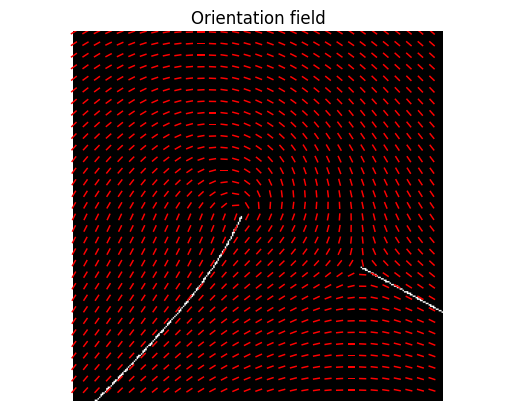

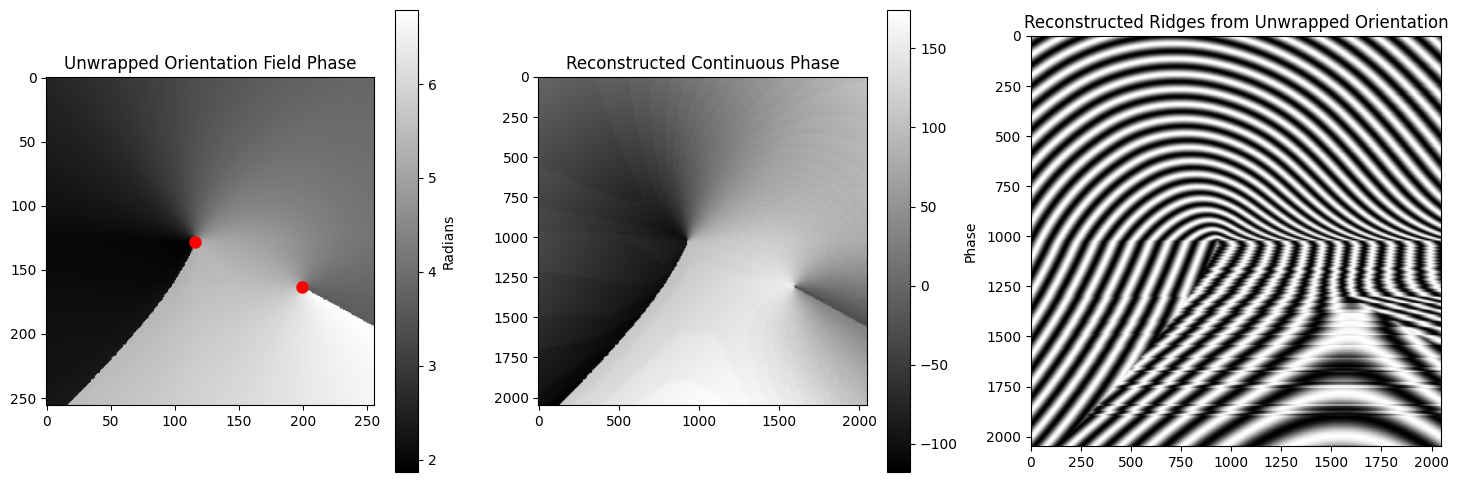

In [ ]:
print(delta_positions, core_positions)
singularities = [(int(complex_num.x), int(complex_num.y)) for complex_num in delta_positions + core_positions if 0 < complex_num.x < height and 0 < complex_num.y < width]
print("Singularities:", singularities)

# unwrapped_orientation_phase = unwrap_orientation_field(
#     orientation_field[0].numpy(), mask=np.ones_like(orientation_field[0].numpy(), dtype=bool)
# )
branch_cuts = get_smart_branch_cuts(
    orientation_field[0].numpy(),
    mask=np.ones_like(orientation_field[0].numpy(), dtype=bool),
    singularities=singularities,
)


unwrapped_orientation_phase = feng_jain_unwrap(
    orientation_field[0].numpy(),
    mask=np.ones_like(orientation_field[0].numpy(), dtype=bool),
    branch_cuts=branch_cuts,
)

plt.imshow(branch_cuts, cmap="gray")
plt.title("Branch Cuts")

quiver_plot(orientation_field)

continuous_phase_reconstructed = reconstruct_continuous_phase(
    unwrapped_orientation_phase,
    spiral_gradient_x=np.zeros_like(unwrapped_orientation_phase),
    spiral_gradient_y=np.zeros_like(unwrapped_orientation_phase),
    mask=np.ones_like(unwrapped_orientation_phase, dtype=bool),
    f=0.012,
    block_size=8,
)

plt.figure(figsize=(18, 6))

plt.subplot(1, 3, 1)
plt.title("Unwrapped Orientation Field Phase")
plt.imshow(unwrapped_orientation_phase, cmap="gray")

# for item in core_positions + delta_positions:
#     cx, cy = int(item.x), int(item.y)
#     if 0 < cx < height and 0 < cy < width:
#         plt.plot(cx, cy, "ro", markersize=8, label="Core")

plt.colorbar(label="Radians")

plt.subplot(1, 3, 2)
plt.title("Reconstructed Continuous Phase")
plt.imshow(continuous_phase_reconstructed, cmap="gray")
plt.colorbar(label="Phase")

plt.subplot(1, 3, 3)
plt.title("Reconstructed Ridges from Unwrapped Orientation")
plt.imshow(np.cos(continuous_phase_reconstructed), cmap="gray")
plt.show()